# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

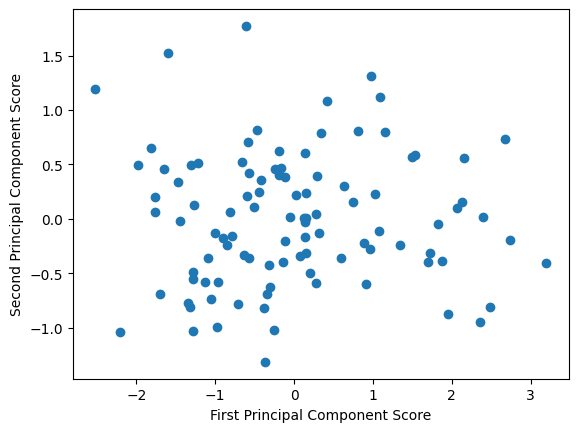

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import decomposition
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn import metrics
import kagglehub
import os

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [2]:
# Load Dataset

path2 = kagglehub.dataset_download("danb91/covid-ppp-loan-data-with-fraud-examples")
print("Path to dataset files:", path2)
files2 = os.listdir(path2)

csv_file2 = os.path.join(path2, files2[2])


df_loan = pd.read_csv(csv_file2)

Path to dataset files: C:\Users\alh55\.cache\kagglehub\datasets\danb91\covid-ppp-loan-data-with-fraud-examples\versions\1


In [3]:
df_loan.head()

,LoanNumber,DateApproved,SBAOfficeCode,ProcessingMethod,BorrowerName,BorrowerAddress,BorrowerCity,BorrowerState,BorrowerZip,LoanStatusDate,...,TOTAL_PROCEED,PROCEED_Diff,UTILITIES_PROCEED_pct,PAYROLL_PROCEED_pct,MORTGAGE_INTEREST_PROCEED_pct,RENT_PROCEED_pct,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job
0,9547507704,2020-05-01,464,PPP,sumter coatings inc,2410 highway 15 south,sumter,UNK,29150-9662,2020-12-18,...,769358.78,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,12409.01
1,9777677704,2020-05-01,464,PPP,pleasant places inc,7684 southrail road,north charleston,UNK,29420-9000,2021-09-28,...,736927.79,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,10094.90
2,5791407702,2020-05-01,1013,PPP,boyer childrens clinic,1850 boyer ave e,seattle,UNK,98112-2922,2021-03-17,...,691355.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,9218.07
3,6223567700,2020-05-01,920,PPP,kirtley construction inc,1661 martin ranch rd,san bernardino,UNK,92407-1740,2021-10-16,...,499871.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,23803.38
4,9662437702,2020-05-01,101,PPP,aero box llc,unknown,unknown,UNK,0,2021-08-17,...,367437.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,14697.48


c:\Users\alh55\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\matplotlib\colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
c:\Users\alh55\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\matplotlib\colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
C:\Users\alh55\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


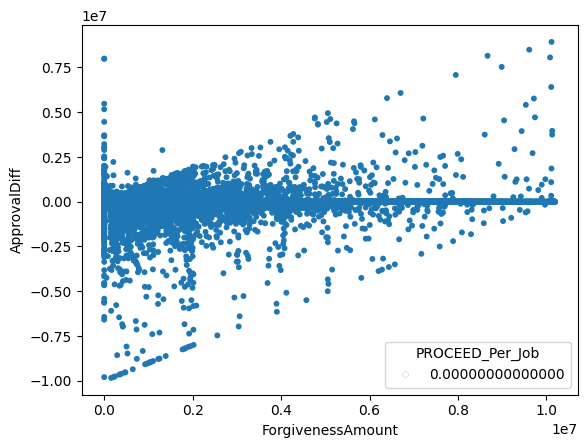

In [ ]:
# Bubble plot
ax1 = sns.scatterplot(df_loan,x='ForgivenessAmount', y='ApprovalDiff', size='PROCEED_Per_Job')


C:\Users\alh55\AppData\Roaming\Python\Python314\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\alh55\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


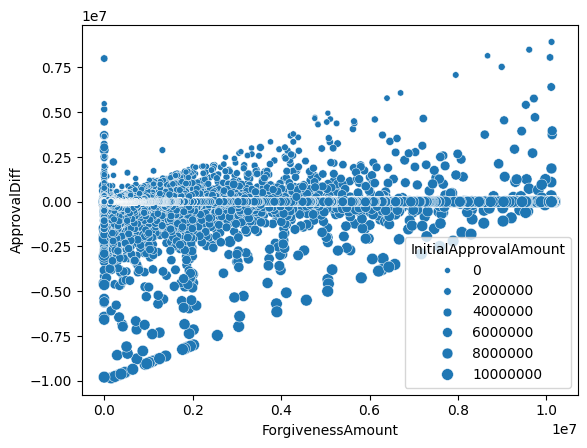

In [10]:
# Bubble plot 

ax1 = sns.scatterplot(df_loan.select_dtypes(include=[np.number]).drop('PROCEED_Per_Job',axis=1),x='ForgivenessAmount', y='ApprovalDiff', size='InitialApprovalAmount')

In [14]:
# PCA

pca = decomposition.PCA(n_components=3)
pca.fit(df_loan.select_dtypes(include=[np.number]).drop('PROCEED_Per_Job',axis=1))
print("PCA for 6 n_components")
print(f"The first principal component explains {pca.explained_variance_ratio_[0]} of the variance")
print(f"The second principal component explains {pca.explained_variance_ratio_[1]} of the variance")
print(f"The components_ vector is = {pca.components_}")

PCA for 6 n_components
The first principal component explains 0.9999995642405992 of the variance
The second principal component explains 3.980443895452194e-07 of the variance
The components_ vector is = [[ 1.00000000e+00 -6.89390892e-10 -4.57742220e-10  8.12131855e-23
   2.58150454e-06  2.66020826e-06 -1.36019518e-09 -1.60216878e-07
  -2.76598842e-10 -6.30184011e-07  1.25455447e-07  2.49787650e-06
   3.04939907e-08  3.82255472e-08 -4.57817993e-09 -3.68173471e-08
   9.32472001e-09 -1.51694539e-07  3.37804910e-06  7.87037145e-08
  -7.17840845e-07  1.66397575e-12  2.65998068e-06  2.27574306e-10
   1.71486471e-13  3.24672467e-13  5.72512608e-14 -2.67496478e-13
  -2.60443552e-14 -2.35046375e-13 -2.55934087e-14]
 [-6.11407839e-06 -1.08316472e-06 -8.49214207e-07  1.07049441e-18
   4.58422349e-01  4.57096721e-01  1.25455547e-05 -1.42600049e-03
   3.16444185e-05 -5.61823706e-03  5.06110103e-03  4.39855577e-01
   2.82824078e-03  5.39411574e-03  2.69397284e-05  3.35764780e-03
   5.73370782e-04 -1

## PCA 

### PCA explains 99% of the variance in the first principal component which is the majority of the variance. The second principal component only explains .0000003% of the varaince.

In [16]:
# Linear Regression

def check_MSE_for_feature(feat):
    linreg = linear_model.LinearRegression()
    linreg.fit(df_loan.select_dtypes(include=[np.number]).drop( columns=['PROCEED_Per_Job',feat]),df_loan[feat])
    pred = linreg.predict(df_loan.select_dtypes(include=[np.number]).drop( columns=['PROCEED_Per_Job',feat]))
    print(metrics.mean_squared_error(df_loan[feat],pred))

for feat in df_loan.select_dtypes(include=[np.number]).columns:
    if feat != 'PROCEED_Per_Job':
        print(f"MSE for {feat}")
        check_MSE_for_feature(feat)
        print('-----'*10)

MSE for LoanNumber
6.459455791595469e+18
--------------------------------------------------
MSE for SBAOfficeCode
68924.43050587703
--------------------------------------------------
MSE for Term
279.8654435947178
--------------------------------------------------
MSE for SBAGuarantyPercentage
0.0
--------------------------------------------------
MSE for InitialApprovalAmount
9.855673488612483e-12
--------------------------------------------------
MSE for CurrentApprovalAmount
2.0417355842892456e-14
--------------------------------------------------
MSE for UndisbursedAmount
22810864.209898625
--------------------------------------------------
MSE for ServicingLenderLocationID
1291238673.4386964
--------------------------------------------------
MSE for JobsReported
1907.7424874978594
--------------------------------------------------
MSE for NAICSCode
33207914118.347855
--------------------------------------------------
MSE for UTILITIES_PROCEED
7.894282633659821e-12
----------------

## Regression questions

### Regression with the numeric columns predicts most other columns very accurately. The above example shows prediction though some of the higher MSE are for numeric columns that are actually catergorical like IDs.

## Conclusion

### The numeric columns in this dataset are good for predicting any of the other non categorical numeric colmns. The `PROCEED_Per_Job` column had to be droped due to too many $inf$ values

## 

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

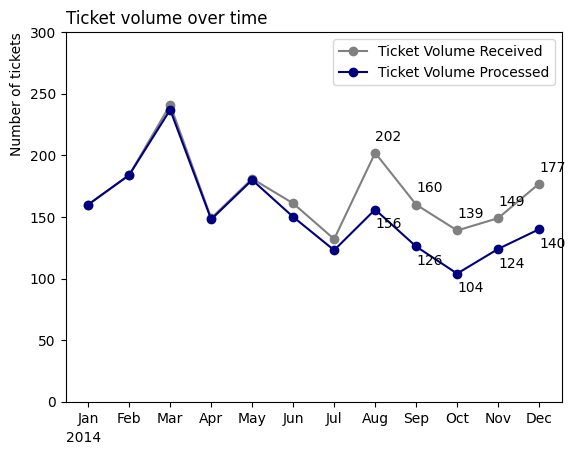

In [43]:
# Figure 5.13 pg 148

import matplotlib.pyplot as plt

# p115 Fig 4.13

proc = [160,184,237,148,180,150,123,156,126,104,124,140]
rec = [160,184,241,149,181,161,132,202,160,139,149,177]
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for i in range(len(rec)):
    if i> 6:
        plt.text(months[i],rec[i]+10,str(rec[i]))
        plt.text(months[i],proc[i]-15,str(proc[i]))

plt.plot(months,rec,'o-',label='Ticket Volume Received',color='grey')
plt.plot(months,proc,'o-',label='Ticket Volume Processed',color='navy')
plt.ylim(0,300)
plt.title("Ticket volume over time",loc='left')
plt.xlabel("2014",loc='left')
plt.ylabel("Number of tickets",loc='top')
plt.legend()